In [1]:
# importing packages and modules
import numpy as np
import matplotlib as mpl
import scipy.stats as stats
from scipy.optimize import minimize, check_grad
from io_utils import *
from utils import *
from plotting_utils import *
from analysis_utils import *
import dynamic_glmhmm
from scipy.stats import multivariate_normal, norm
sns.set_context("talk")

colormap = ['tab:purple','tab:pink','tab:cyan','yellowgreen', 'olive']
colorsStates = ['tab:orange','tab:blue','tab:green','tab:purple', 'tab:brown']
myFeatures = [['bias','stimulus', 'previous choice', 'previous reward'],['bias','contrast left','contrast right', 'previous choice', 'previous reward']]
ibl_data_path = '../data_IBL'
# dfAll = pd.read_csv(ibl_data_path + '/Ibl_processed.csv')
dfAll = pd.read_csv(ibl_data_path + '/IBL_processed_extra.csv')

labChosen =  ['angelakilab','churchlandlab','wittenlab']
subjectsAll = []
for lab in labChosen:
    subjects = np.unique(dfAll[dfAll['lab'] == lab]['subject']).tolist()
    subjectsAll = subjectsAll + subjects

# missing data
if ('NYU-01' in subjectsAll):
    subjectsAll.remove('NYU-01')
if ('NYU-06' in subjectsAll):
    subjectsAll.remove('NYU-06')
if ('CSHL_007' in subjectsAll):
    subjectsAll.remove('CSHL_007')
if ('CSHL049' in subjectsAll):
    subjectsAll.remove('CSHL049')
if ('CSHL024' in subjectsAll):
    subjectsAll.remove('CSHL024')


In [2]:
dfAll.head()

,contrastLeft,contrastRight,choice,feedbackType,probabilityLeft,lab,subject,date,session,correctSide,response_times,RT
0,1.0,0.0,1.0,0.0,1.0,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN
1,1.0,0.0,1.0,0.0,1.0,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN
2,0.0,1.0,1.0,1.0,1.0,angelakilab,IBL-T1,2019-02-09,1.0,1.0,NaN,NaN
3,0.5,0.0,0.0,1.0,0.5,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN
4,0.5,0.0,0.0,1.0,0.9,angelakilab,IBL-T1,2019-02-09,1.0,0.0,NaN,NaN


# Simulations to show number of trials needed to recover good weights

In [3]:
sessions = [25, 50]
trials = [100,200,400,800]
Nsamples = 20

K = 3
D = 2
pTanh = 5
signedStimulus = True
sessStop = None

avg_model = np.load(f'../data_IBL/average_animals_fig4-5_best_parameters_dynamic.npz')
dynamicW = avg_model['bestAvgW']
dynamicP = avg_model['bestAvgP']
dynamicpi = np.ones((K))/K
truepi = np.ones((K))/K

subject = 'ibl_witten_15'
x, y, sessInd_old, correctSide, responseTimes = get_mouse_design(dfAll, subject, sessStop=None, signedStimulus=signedStimulus, pTanh=pTanh)
biasedBlockTrials, biasedBlockStartInd, biasedBlockSession, firstBlockSession = get_design_biased_blocks(dfAll, subject, sessInd_old, sessStop)
N = x.shape[0]
sess = len(sessInd_old)-1
x = x[:,:2] # only keeping bias and stimulus




In [4]:


standard_model = np.load(f'../data_IBL/all_animals/Best_allAnimals_standardGLMHMM_{K}-state_pTanh={pTanh}_signedStimulus={signedStimulus}.npz')
standardP = standard_model['P'][:50]
standardW = standard_model['W'][:50,:,:2]

print(dynamicW.shape)
print(standardW.shape)
print(standardP.shape)

(50, 3, 2, 2)
(50, 3, 2, 2)
(50, 3, 3)


In [5]:

print(dynamicP[0].sum(axis=1))
print(standardP[0].sum(axis=1))

# normalizing transition  matrix
for s in range(50):
    for j in range(K):
        dynamicP[s,j,:] = dynamicP[s,j,:] / dynamicP[s,j,:].sum()
        standardP[s,j,:] = standardP[s,j,:] / standardP[s,j,:].sum()

print(dynamicP[0].sum(axis=1))
print(standardP[0].sum(axis=1))

[0.99999783 0.99999754 0.9999979 ]
[0.99999992 0.99999957 0.99999945]
[1. 1. 1.]
[1. 1. 1.]


In [10]:
print(trueW[:,0,0,1])
print(W[:,0,0,1])

[ 0.07735593  0.07735593  0.07735593 ... -0.21478326 -0.21478326
 -0.21478326]
[ 0.08267056  0.08267056  0.08267056 ... -2.30852323 -2.30852323
 -2.30852323]


In [79]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
# from oneibl.onelight import ONE # only used for downloading data
# import wget
from utils import *
from plotting_utils import *
from analysis_utils import *
import dynamic_glmhmm
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
import sys
import os
from io_utils import *

colormap = ['tab:purple','tab:pink','tab:cyan','yellowgreen', 'olive']
colorsStates = ['tab:orange','tab:blue','tab:green','tab:purple', 'tab:brown']
myFeatures = [['bias','stimulus', 'previous choice', 'previous reward'],['bias','contrast left','contrast right', 'previous choice', 'previous reward']]
ibl_data_path = '../data_IBL'
# dfAll = pd.read_csv(ibl_data_path + '/Ibl_processed.csv')
dfAll = pd.read_csv(ibl_data_path + '/IBL_processed_extra.csv')

sessions = [25, 50]
trials = [100,200,400,800]
Nsamples = 20

df = pd.DataFrame(columns=['init','K','signedStimulus', 'pTanh']) # in total z=0,399 inclusively
z = 0
for Nsess in sessions:
    for Ntrial in trials:
        for Nsample in range(Nsamples):
            df.loc[z, 'Nsess'] = Nsess
            df.loc[z, 'Ntrial'] = Ntrial
            df.loc[z, 'Nsample'] = Nsample
            z += 1

# read from cluster array in order to get parallelizations
idx = 0 #int(os.environ["SLURM_ARRAY_TASK_ID"])
Nsess = int(df.loc[idx,'Nsess'])
# Ntrial = int(df.loc[idx,'Ntrial'])
Ntrial = 200
Nsample = int(df.loc[idx, 'Nsample'])

K = 3
D = 2
pTanh = 5
signedStimulus = True
sessStop = None

avg_model = np.load(f'../data_IBL/average_animals_fig4-5_best_parameters_dynamic.npz')
dynamicW = avg_model['bestAvgW']
dynamicP = avg_model['bestAvgP']
dynamicpi = np.ones((K))/K
truepi = np.ones((K))/K

subject = 'ibl_witten_15'
x, y, sessInd_old, correctSide, responseTimes = get_mouse_design(dfAll, subject, sessStop=None, signedStimulus=signedStimulus, pTanh=pTanh)
biasedBlockTrials, biasedBlockStartInd, biasedBlockSession, firstBlockSession = get_design_biased_blocks(dfAll, subject, sessInd_old, sessStop)
N = x.shape[0]
sess = len(sessInd_old)-1
x = x[:,:2] # only keeping bias and stimulus

standard_model = np.load(f'../data_IBL/all_animals/Best_allAnimals_standardGLMHMM_{K}-state_pTanh={pTanh}_signedStimulus={signedStimulus}.npz')
standardP = standard_model['P'][:50]
standardW = standard_model['W'][:50,:,:2]

# normalizing transition  matrix
for s in range(50):
    for j in range(K):
        dynamicP[s,j,:] = dynamicP[s,j,:] / dynamicP[s,j,:].sum()
        standardP[s,j,:] = standardP[s,j,:] / standardP[s,j,:].sum()

sigmaList = [10**x for x in list(np.arange(-3,1,0.5,dtype=float))] + [10**x for x in list(np.arange(1,4,1,dtype=float))]
bestSigmaInd = 7 
bestSigma = sigmaList[bestSigmaInd-1]
print(bestSigma)
alphaList = [2*(10**x) for x in list(np.arange(-1,6,0.5,dtype=float))]
bestAlphaInd = 3  # Choosing best sigma index across animals
bestAlpha = alphaList[bestAlphaInd]
print(bestAlpha)
maxiter = 200

rng = np.random.default_rng(42)

truex = np.ones((Nsess * Ntrial, 2))
sessInd= [i * Ntrial for i in range(Nsess+1)]
for s in range(Nsess):
    truex[Ntrial * s : Ntrial * s + Ntrial, 1] = rng.choice(x[sessInd_old[s]:sessInd_old[s+1],1], size=Ntrial, replace=True).flatten()
        
N = truex.shape[0]
dGLM_HMM = dynamic_glmhmm.dynamic_GLMHMM(N,K,D,2)
trueW, trueP = reshape_parameters_session_to_trials(dynamicW[:Nsess+1], dynamicP[:Nsess+1], sessInd)
initW, initP = reshape_parameters_session_to_trials(standardW[:Nsess+1], standardP[:Nsess+1], sessInd)

truey, truez = dGLM_HMM.simulate_data_given_x(truex, trueW, trueP, truepi, sessInd, seed=Nsample)

presentAll = np.ones((N))
fitP, _, fitW, trainLl = dGLM_HMM.fit(truex, truey, presentAll, initP, truepi, initW, sigma=reshapeSigma(bestSigma, K, D), alpha=bestAlpha, A=standardP[0], sessInd=sessInd, maxIter=maxiter, tol=1e-3, model_type='dynamic',  L2penaltyW=0, priorDirP = None, fit_init_states=True)
# np.savez(f'../simulations/dynamicGLMHMM_simulation_NatComms_sample={Nsample}_Nsess={Nsess}_Ntrial={Ntrial}', P=fitP, W=fitW, y=truey, z=truez, x=truex, trueW=trueW, trueP=trueP)


1.0
20.0
0
50


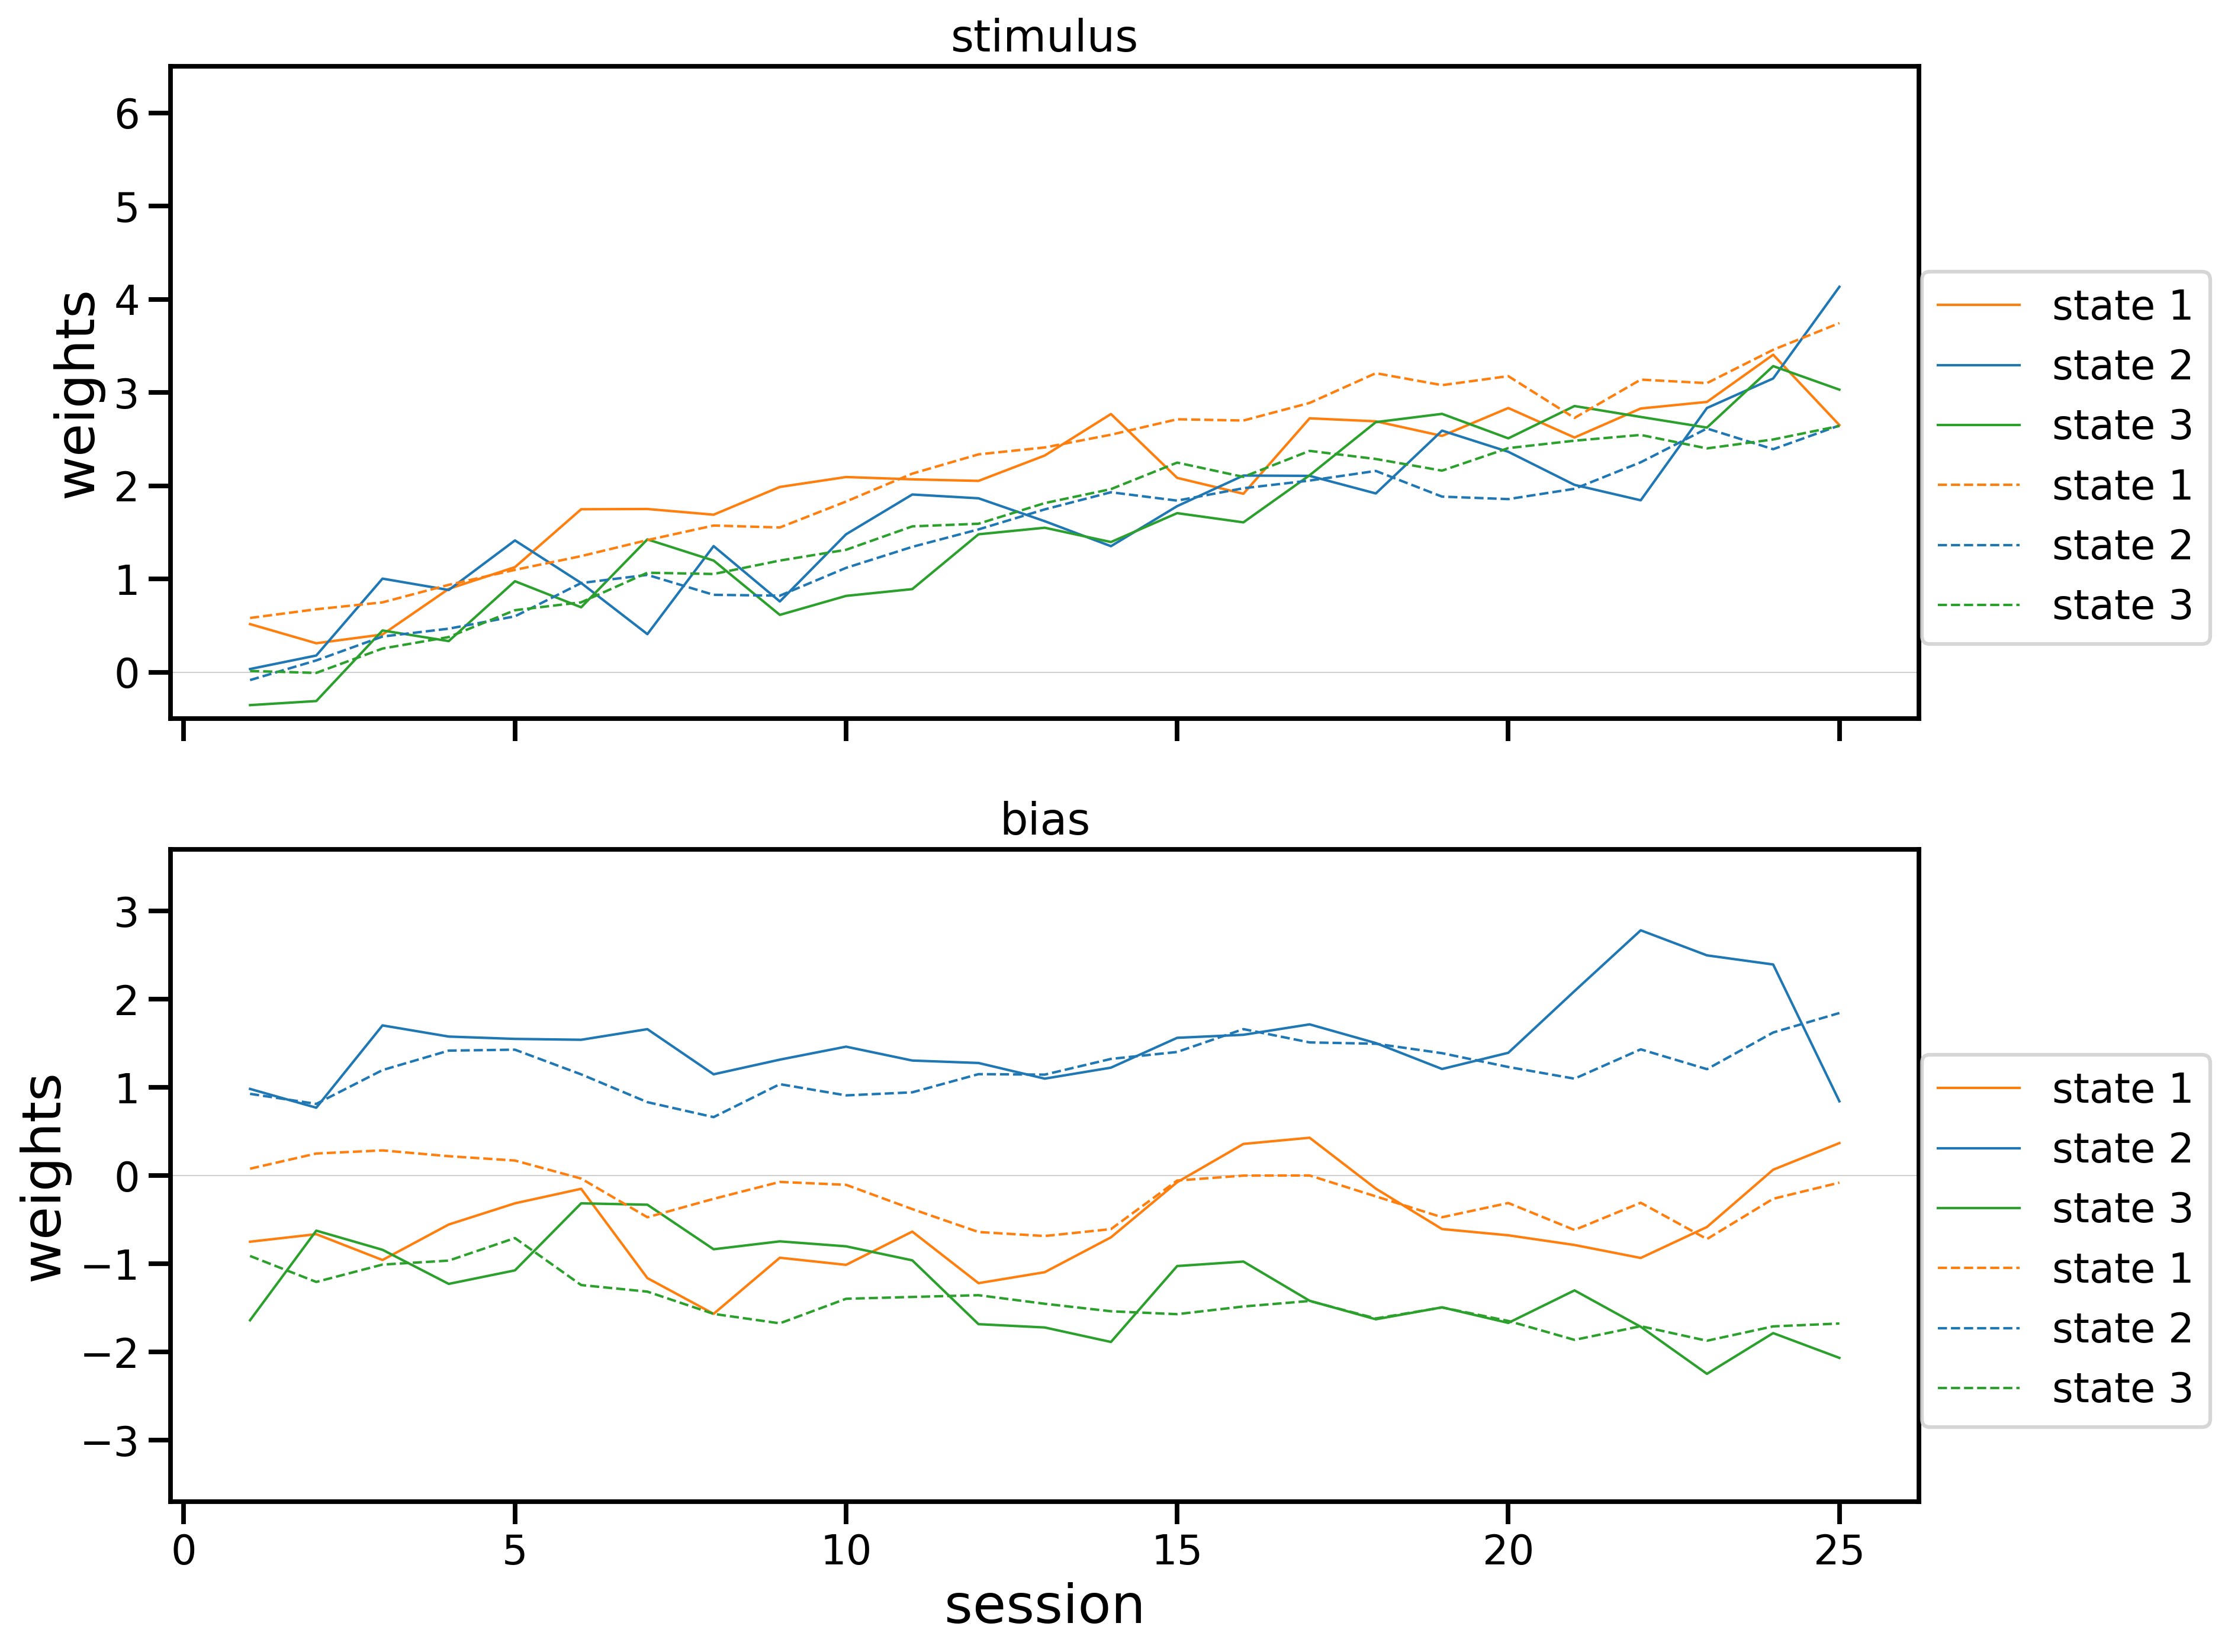

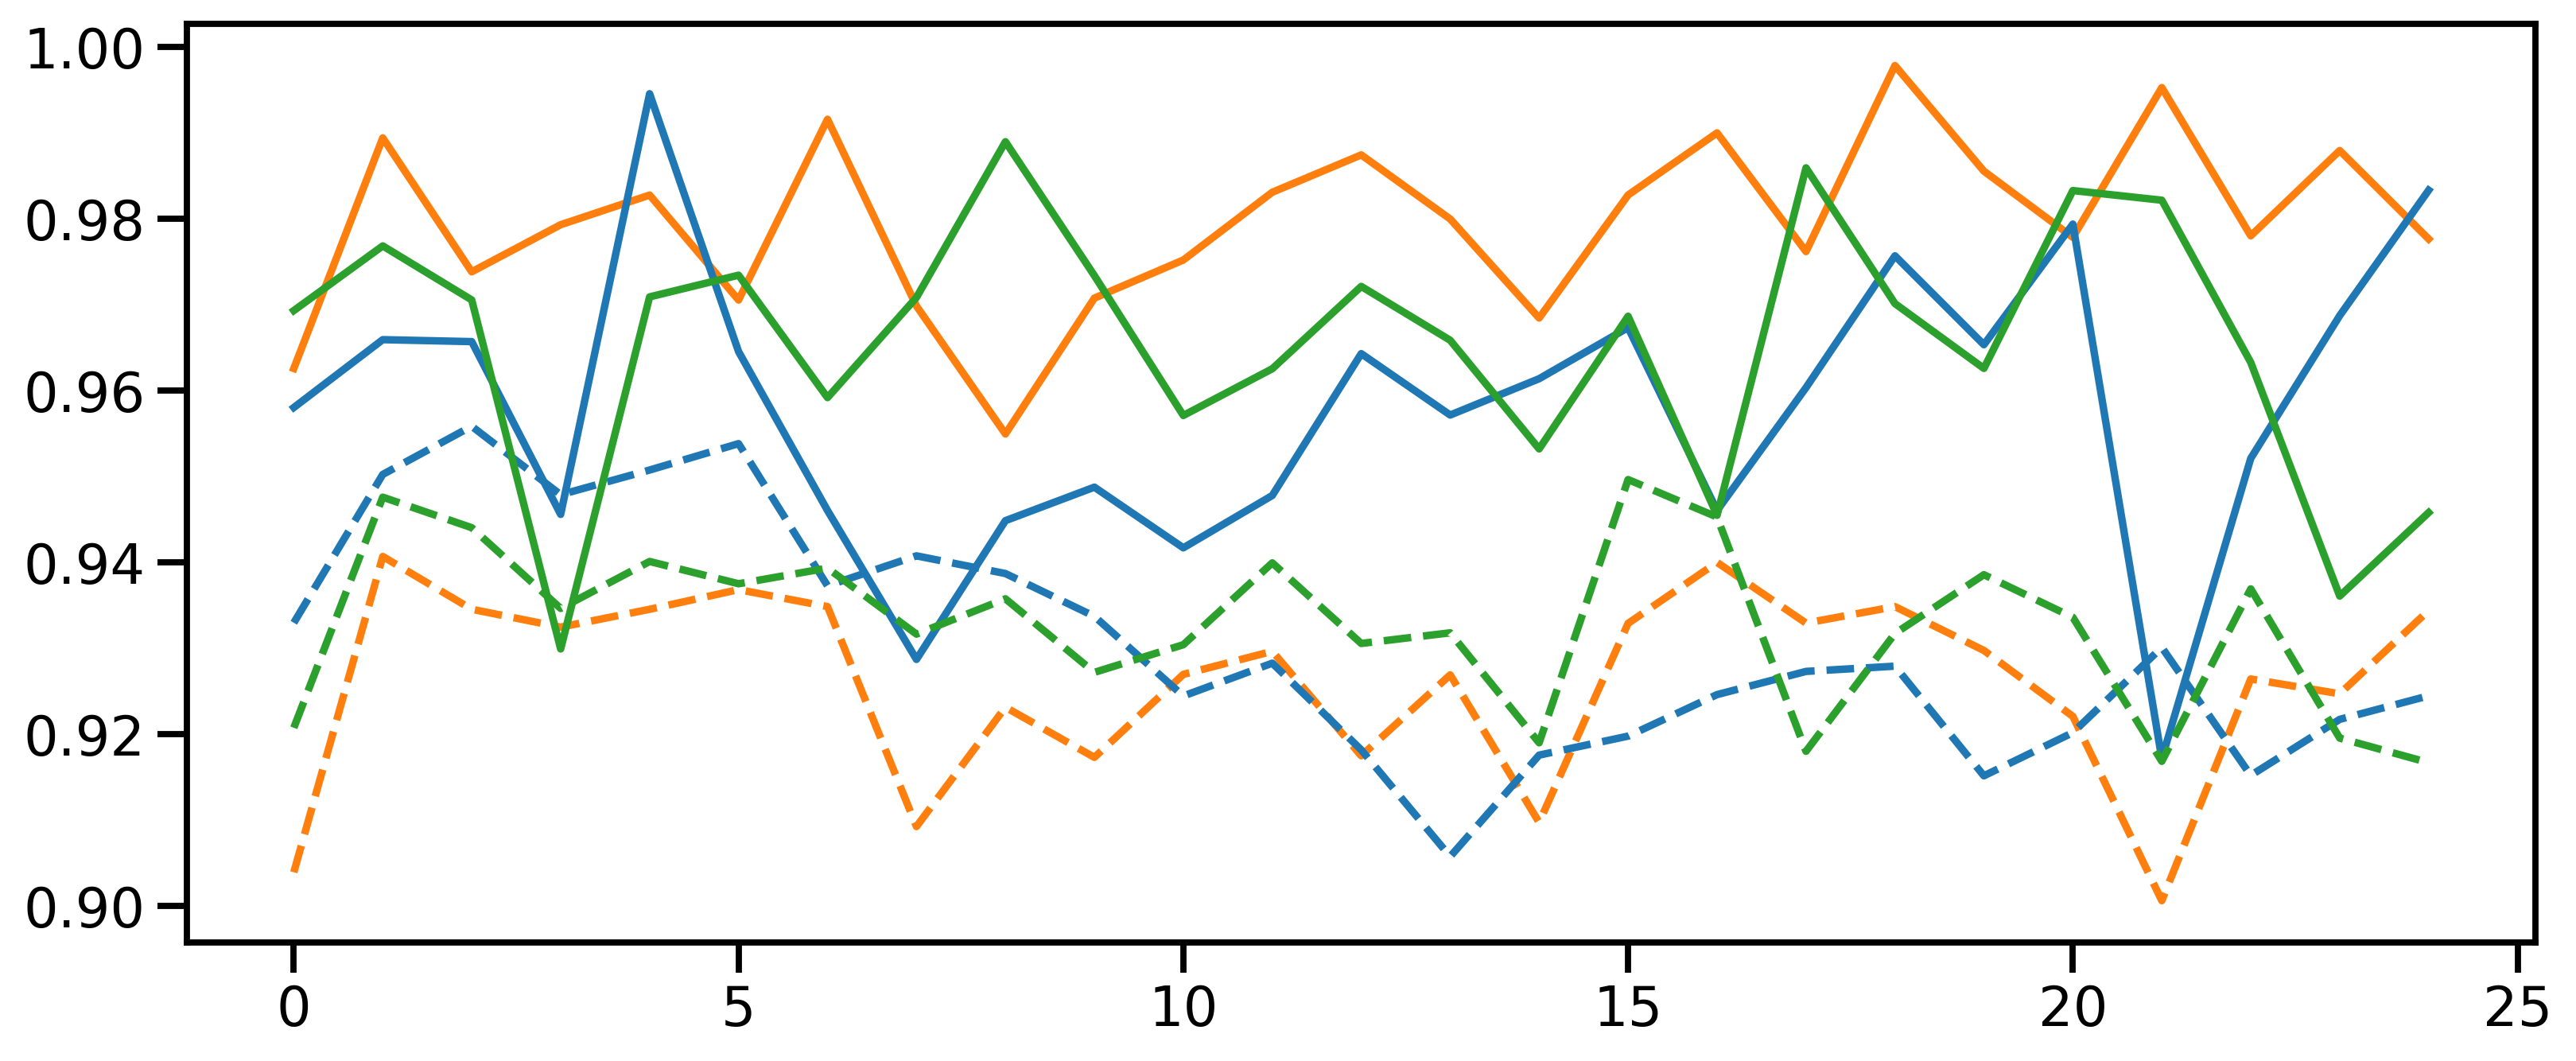

In [80]:
fig, axes = plt.subplots(2, 1,figsize=(12.7,10.5), sharex=True, dpi=300)
yLim=[[-0.5,6.5],[-3.7,3.7],[-3.7,3.7],[-3.7,3.7]]
plotting_weights_per_feature(fitW[:,:,[1,0],:], sessInd, axes, yLim=yLim, colors=colorsStates, labels=['stimulus','bias'], linewidth=1, linestyle='-', alpha=1, legend=True, sortedStateInd=None)
plotting_weights_per_feature(trueW[:,:,[1,0],:], sessInd, axes, yLim=yLim, colors=colorsStates, labels=['stimulus','bias'], linewidth=1, linestyle='--', alpha=1, legend=True, sortedStateInd=None)

fig, axes = plt.subplots(figsize=(12.7,5), sharex=True, dpi=300)
for k in range(K):  
    axes.plot(fitP[sessInd[:-1],k,k], '-',color=colorsStates[k])
    axes.plot(trueP[sessInd[:-1],k,k], '--',color=colorsStates[k])

In [44]:
sigmaList = [10**x for x in list(np.arange(-3,1,0.5,dtype=float))] + [10**x for x in list(np.arange(1,4,1,dtype=float))]
bestSigmaInd = 8 
bestSigma = sigmaList[bestSigmaInd-1]
alphaList = [2*(10**x) for x in list(np.arange(-1,6,0.5,dtype=float))]
bestAlphaInd = 2  # Choosing best sigma index across animals
bestAlpha = alphaList[bestAlphaInd]
maxiter = 250

# sessions = [25]
# trials = [100]
# Nsamples = 1
sessions = [25, 50]
trials = [100,200,400,800]
Nsamples = 20

mse = np.zeros((50, len(sessions), len(trials), Nsamples, 2))

for Nsess in sessions:
    idxsess = sessions.index(Nsess)
    print(f'session {Nsess}')
    for Ntrial in trials:
        idxtrial = trials.index(Ntrial)
        print(f'Ntrial {Ntrial}')
        for Nsample in range(Nsamples):    
            print(f'sample = {Nsample}')
            params = np.load(f'../simulations/dynamicGLMHMM_simulation_NatComms_sample={Nsample}_Nsess={Nsess}_Ntrial={Ntrial}.npz')
            P = params['P']
            W = params['allW']
            y = params['y']
            z = params['z']
            x = params['x']
            trueW = params['trueW']
            trueP = params['trueP']

            sessInd = [i * Ntrial for i in range(Nsess+1)]

            mse[:Nsess,idxsess,idxtrial,Nsample,0] = np.mean(np.square(W[sessInd[:-1],:,0,1] - trueW[sessInd[:-1],:,0,1]), axis=1)
            mse[:Nsess,idxsess,idxtrial,Nsample,1] = np.mean(np.square(W[sessInd[:-1],:,1,1] - trueW[sessInd[:-1],:,1,1]), axis=1)
            

            # fig, axes = plt.subplots(2, 1,figsize=(12.7,10.5), sharex=True, dpi=300)
            # yLim=[[-0.5,6.5],[-3.7,3.7],[-3.7,3.7],[-3.7,3.7]]
            # plotting_weights_per_feature(W[:,:,[1,0],:], sessInd, axes, yLim=yLim, colors=colorsStates, labels=['stimulus','bias'], linewidth=1, linestyle='-', alpha=1, legend=True, sortedStateInd=None)
            # plotting_weights_per_feature(trueW[:,:,[1,0],:], sessInd, axes, yLim=yLim, colors=colorsStates, labels=['stimulus','bias'], linewidth=1, linestyle='--', alpha=1, legend=True, sortedStateInd=None)


session 25
Ntrial 100
sample = 0
sample = 1
sample = 2
sample = 3
sample = 4
sample = 5
sample = 6
sample = 7
sample = 8
sample = 9
sample = 10
sample = 11
sample = 12
sample = 13
sample = 14
sample = 15
sample = 16
sample = 17
sample = 18
sample = 19
Ntrial 200
sample = 0
sample = 1
sample = 2
sample = 3
sample = 4
sample = 5
sample = 6
sample = 7
sample = 8
sample = 9
sample = 10
sample = 11
sample = 12
sample = 13
sample = 14
sample = 15
sample = 16
sample = 17
sample = 18
sample = 19
Ntrial 400
sample = 0
sample = 1
sample = 2
sample = 3
sample = 4
sample = 5
sample = 6
sample = 7
sample = 8
sample = 9
sample = 10
sample = 11
sample = 12
sample = 13
sample = 14
sample = 15
sample = 16
sample = 17
sample = 18
sample = 19
Ntrial 800
sample = 0
sample = 1
sample = 2
sample = 3
sample = 4
sample = 5
sample = 6
sample = 7
sample = 8
sample = 9
sample = 10
sample = 11
sample = 12
sample = 13
sample = 14
sample = 15
sample = 16
sample = 17
sample = 18
sample = 19
session 50
Ntrial 100
sam

session 50


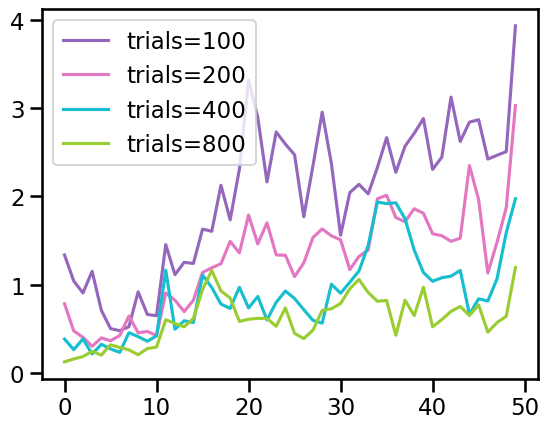

In [51]:
fig, axes = plt.subplots()
for Nsess in sessions[1:]:
    idxsess = sessions.index(Nsess)
    print(f'session {Nsess}')
    for Ntrial in trials:
        idxtrial = trials.index(Ntrial)
        axes.plot(mse[:Nsess,idxsess,idxtrial,:,1].mean(axis=-1), color=colormap[idxtrial], label=f'trials={Ntrial}')

axes.legend()

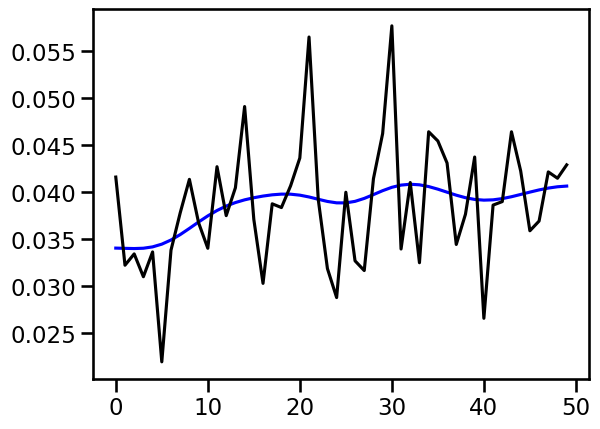

In [35]:
from scipy.ndimage import gaussian_filter1d
# x = np.random.randn(50)  # your vector
sigma = 4           # controls smoothing strength
x = dynamicP[:,0,1]
smoothed = gaussian_filter1d(x, sigma=sigma)
fig, axes = plt.subplots()
axes.plot(smoothed, color='blue')
axes.plot(x, color='black')

In [36]:
smoothList = [0, 0.5,1,2,4]

for 



SyntaxError: invalid syntax (2171449146.py, line 3)